In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

In [2]:
# ============================================================
# PATHS
# ============================================================
UCDB_GPKG = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\GHS_STAT_UCDB2015MT_GLOBE_R2019A\GHS_STAT_UCDB2015MT_GLOBE_R2019A_V1_2_with_GHSPOP2023.gpkg"
)

PREDICTIONS_FOLDER = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\predictions"
)

SUMMARY_DIR = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis"
)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ============================================================
# SETTINGS
# ============================================================
VALID_BLOCKS_THRESHOLD = 80.0

TARGET_REGIONS = ["Africa", "Asia", "Latin America and the Caribbean"]

SIZE_ORDER = ["Small", "Medium", "Large", "Very large", "Megacity"]

# UCDB columns
UCDB_ID_COL   = "ID_HDC_G0"
UCDB_POP_COL  = "GHSPOP2023"
UCDB_REG1_COL = "GRGN_L1"
UCDB_REG2_COL = "GRGN_L2"

# Prediction columns expected
PRED_ID_COL   = "ID_HDC_G0"
PRED_REG1_COL = "REG1_GHSL"
PRED_REG2_COL = "REG2_GHSL"
PRED_CITY_COL = "UC_NM_MN"
PRED_LABEL_COL = "rf_label"
PRED_POP_COL   = "POP_SEG"

In [4]:
def classify_city_size(pop):
    pop = 0 if pd.isna(pop) else float(pop)
    if pop < 500_000:
        return "Small"
    elif pop < 1_000_000:
        return "Medium"
    elif pop < 5_000_000:
        return "Large"
    elif pop < 10_000_000:
        return "Very large"
    else:
        return "Megacity"

In [5]:
one_file = list(PREDICTIONS_FOLDER.glob("*_rf_preds.gpkg"))[0]
tmp = gpd.read_file(one_file)

print("Example file:", one_file.name)
print(tmp.columns.tolist())
tmp.head()

Example file: afghanistan_rf_preds.gpkg
['ID_HDC_G0', 'UC_NM_MN', 'UC_NM_LST', 'CTR_MN_NM', 'REG1_GHSL', 'REG2_GHSL', 'ID_SEG', 'SES_3CAT_U', 'SES_2CAT_U', 'SES_3CAT_P', 'SES_2CAT_P', 'SES_3CAT_C', 'SES_2CAT_C', 'JOIN_KEY', 'POP_SEG', 'AREAHA_SEG', 'ROAD_SEG', 'PAR_N_SEG', 'PARU_N_SEG', 'PARU_P_SEG', 'PARU_A_SEG', 'PAR_CV_SEG', 'PAR_A_U', 'B_AREA_SEG', 'B_AVG_SEG', 'B_CV_SEG', 'POP25_U', 'SIZE_U', 'i5_par_area', 'i5_par_area_rel_U', 'i5_ref_U', 'i5_par_area_rel_P', 'i5_ref_P', 'i5_par_area_rel_C', 'i5_ref_C', 'i9_roads_par', 'i9_roads_par_rel_U', 'i9_ref_U', 'i9_roads_par_rel_P', 'i9_ref_P', 'i9_roads_par_rel_C', 'i9_ref_C', 'i1_pop_area', 'i2_pop_par', 'i3_pop_paru', 'i4_pop_roads', 'i6_paru_area', 'i7_roads_area', 'i8_paru_par', 'i10_roads_paru', 'REGION_CODE', 'rf_prob', 'rf_label', 'geometry']


,ID_HDC_G0,UC_NM_MN,UC_NM_LST,CTR_MN_NM,REG1_GHSL,REG2_GHSL,ID_SEG,SES_3CAT_U,SES_2CAT_U,SES_3CAT_P,...,i3_pop_paru,i4_pop_roads,i6_paru_area,i7_roads_area,i8_paru_par,i10_roads_paru,REGION_CODE,rf_prob,rf_label,geometry
0,6119.0,Bagram,Bagram,Afghanistan,Asia,South-Central Asia,0,2.0,1.0,2.0,...,6.084256,0.234917,1858.985915,139.320874,0.546154,25.899554,1,0.034152,0,"POLYGON ((69.23581 34.9324, 69.23585 34.93177,..."
1,6119.0,Bagram,Bagram,Afghanistan,Asia,South-Central Asia,1,2.0,1.0,1.0,...,5.914964,0.282543,2385.240385,87.767763,0.634146,20.934721,1,0.010671,0,"POLYGON ((69.22659 34.92828, 69.22574 34.92828..."
2,6119.0,Bagram,Bagram,Afghanistan,Asia,South-Central Asia,2,2.0,1.0,1.0,...,10.861943,0.377167,2162.760000,133.157491,0.510204,28.798769,1,0.038227,0,"POLYGON ((69.23251 34.93002, 69.23303 34.92927..."
3,6119.0,Bagram,Bagram,Afghanistan,Asia,South-Central Asia,3,2.0,1.0,2.0,...,14.625052,0.327098,1651.279412,270.768705,0.373626,44.711479,1,0.063142,0,"POLYGON ((69.23519 34.9325, 69.23504 34.93186,..."
4,6119.0,Bagram,Bagram,Afghanistan,Asia,South-Central Asia,4,1.0,0.0,0.0,...,12.563439,0.265069,8638.111111,54.869564,0.500000,47.396939,1,0.006166,0,"POLYGON ((69.24755 34.93474, 69.24777 34.93438..."


In [6]:
records = []

required_cols = [
    PRED_ID_COL,
    PRED_REG1_COL,
    PRED_REG2_COL,
    PRED_CITY_COL,
    PRED_LABEL_COL,
    PRED_POP_COL,
]

for file in PREDICTIONS_FOLDER.glob("*_rf_preds.gpkg"):
    country = file.stem.replace("_rf_preds", "")

    try:
        gdf = gpd.read_file(file, columns=required_cols)
    except Exception as e:
        print(f"⚠️ Skipping {file.name} due to error: {e}")
        continue

    missing = [c for c in required_cols if c not in gdf.columns]
    if missing:
        print(f"⚠️ Skipping {file.name} because missing columns: {missing}")
        continue

    # keep ID as string
    gdf[PRED_ID_COL] = gdf[PRED_ID_COL].astype(str)

    # valid block = both rf_label and POP_SEG present
    gdf["valid"] = ~(gdf[PRED_LABEL_COL].isna() | gdf[PRED_POP_COL].isna())

    # group by city ID, not city name
    for city_id, sub in gdf.groupby(PRED_ID_COL):
        total_blocks = len(sub)
        valid_blocks = int(sub["valid"].sum())
        pct_valid = (valid_blocks / total_blocks * 100) if total_blocks > 0 else 0.0

        if pct_valid < VALID_BLOCKS_THRESHOLD:
            continue

        sub_valid = sub[sub["valid"]].copy()

        total_pop = float(sub_valid[PRED_POP_COL].sum())
        deprived_pop = float(
            sub_valid.loc[sub_valid[PRED_LABEL_COL] == 1, PRED_POP_COL].sum()
        )
        pct_deprived = (deprived_pop / total_pop * 100) if total_pop > 0 else 0.0

        records.append({
            "ID_HDC_G0": city_id,
            "Region": sub[PRED_REG1_COL].iloc[0],
            "Region_L2_pred": sub[PRED_REG2_COL].iloc[0],
            "Country": country,
            "City": sub[PRED_CITY_COL].iloc[0],
            "TotalBlocks": total_blocks,
            "ValidBlocks": valid_blocks,
            "PctValid": pct_valid,
            "TotalPop": total_pop,
            "DeprivedPop": deprived_pop,
            "PctDeprived": pct_deprived,
        })

city_df = pd.DataFrame(records)

print("Number of cities passing QC (>= 80% valid blocks):", len(city_df))
city_df.head()

Number of cities passing QC (>= 80% valid blocks): 5214


,ID_HDC_G0,Region,Region_L2_pred,Country,City,TotalBlocks,ValidBlocks,PctValid,TotalPop,DeprivedPop,PctDeprived
0,5959.0,Asia,South-Central Asia,afghanistan,Herat,775,775,100.0,1.333792e+06,151072.083843,11.326507
1,5964.0,Asia,South-Central Asia,afghanistan,Guzarah,71,71,100.0,1.647973e+05,0.000000,0.000000
2,5973.0,Asia,South-Central Asia,afghanistan,Farah,124,124,100.0,1.353276e+05,0.000000,0.000000
3,5981.0,Asia,South-Central Asia,afghanistan,Zaranj,44,44,100.0,3.893846e+04,0.000000,0.000000
4,5992.0,Asia,South-Central Asia,afghanistan,Maymana,147,147,100.0,1.170994e+05,0.000000,0.000000


In [7]:
city_deprivation_csv = SUMMARY_DIR / "city_deprivation_80pct_with_ids_regionL2.csv"
city_df.to_csv(city_deprivation_csv, index=False, encoding="utf-8")

print(f"Saved city-level QC CSV to:\n{city_deprivation_csv}")

Saved city-level QC CSV to:
D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\city_deprivation_80pct_with_ids_regionL2.csv


In [8]:
ucdb_layer = gpd.list_layers(UCDB_GPKG).iloc[0]["name"]

ucdb = gpd.read_file(
    UCDB_GPKG,
    layer=ucdb_layer,
    columns=[UCDB_ID_COL, UCDB_REG1_COL, UCDB_REG2_COL, UCDB_POP_COL]
)

ucdb[UCDB_ID_COL] = ucdb[UCDB_ID_COL].astype(str)

ucdb_unique = (
    ucdb[[UCDB_ID_COL, UCDB_REG1_COL, UCDB_REG2_COL, UCDB_POP_COL]]
    .dropna(subset=[UCDB_ID_COL])
    .drop_duplicates(subset=[UCDB_ID_COL])
    .copy()
)

ucdb_unique = ucdb_unique[
    ucdb_unique[UCDB_REG1_COL].isin(TARGET_REGIONS)
].copy()

ucdb_unique["CitySizeClass"] = ucdb_unique[UCDB_POP_COL].apply(classify_city_size)

print("UCDB unique cities:", ucdb_unique.shape)
ucdb_unique.head()

UCDB unique cities: (11618, 5)


,ID_HDC_G0,GRGN_L1,GRGN_L2,GHSPOP2023,CitySizeClass
18,19.0,Latin America and the Caribbean,Central America,78430.922864,Small
19,20.0,Latin America and the Caribbean,Central America,332786.166521,Small
22,23.0,Latin America and the Caribbean,Central America,56171.304272,Small
30,31.0,Latin America and the Caribbean,Central America,69365.726105,Small
42,43.0,Latin America and the Caribbean,Central America,253371.783538,Small


In [9]:
city_df["ID_HDC_G0"] = city_df["ID_HDC_G0"].astype(str)

city_df_enriched = city_df.merge(
    ucdb_unique[[UCDB_ID_COL, UCDB_REG1_COL, UCDB_REG2_COL, UCDB_POP_COL]],
    left_on="ID_HDC_G0",
    right_on=UCDB_ID_COL,
    how="left"
)

# rename to clean final names
city_df_enriched = city_df_enriched.rename(columns={
    UCDB_REG1_COL: "Region_L1",
    UCDB_REG2_COL: "Region_L2",
    UCDB_POP_COL: "UCDB_CityPop"
})

city_df_enriched = city_df_enriched[
    city_df_enriched["Region_L1"].isin(TARGET_REGIONS)
].copy()

# keep city size based on UCDB population for consistency
city_df_enriched["CitySizeClass"] = city_df_enriched["UCDB_CityPop"].apply(classify_city_size)

print("Enriched city table:", city_df_enriched.shape)
city_df_enriched.head()

Enriched city table: (5204, 15)


,ID_HDC_G0,Region,Region_L2_pred,Country,City,TotalBlocks,ValidBlocks,PctValid,TotalPop,DeprivedPop,PctDeprived,Region_L1,Region_L2,UCDB_CityPop,CitySizeClass
0,5959.0,Asia,South-Central Asia,afghanistan,Herat,775,775,100.0,1.333792e+06,151072.083843,11.326507,Asia,South-Central Asia,1.333795e+06,Large
1,5964.0,Asia,South-Central Asia,afghanistan,Guzarah,71,71,100.0,1.647973e+05,0.000000,0.000000,Asia,South-Central Asia,1.647976e+05,Small
2,5973.0,Asia,South-Central Asia,afghanistan,Farah,124,124,100.0,1.353276e+05,0.000000,0.000000,Asia,South-Central Asia,1.353277e+05,Small
3,5981.0,Asia,South-Central Asia,afghanistan,Zaranj,44,44,100.0,3.893846e+04,0.000000,0.000000,Asia,South-Central Asia,3.893846e+04,Small
4,5992.0,Asia,South-Central Asia,afghanistan,Maymana,147,147,100.0,1.170994e+05,0.000000,0.000000,Asia,South-Central Asia,1.170994e+05,Small


In [10]:
missing_ucdb = city_df_enriched["Region_L1"].isna().sum()
print("Cities with missing UCDB region after join:", missing_ucdb)

city_df_enriched[city_df_enriched["Region_L1"].isna()].head()

Cities with missing UCDB region after join: 0


,ID_HDC_G0,Region,Region_L2_pred,Country,City,TotalBlocks,ValidBlocks,PctValid,TotalPop,DeprivedPop,PctDeprived,Region_L1,Region_L2,UCDB_CityPop,CitySizeClass


In [11]:
out_city_enriched = SUMMARY_DIR / "city_deprivation_80pct_qc_with_ucdb_regions.csv"
city_df_enriched.to_csv(out_city_enriched, index=False, encoding="utf-8")

print(f"Saved enriched city-level table to:\n{out_city_enriched}")

Saved enriched city-level table to:
D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\city_deprivation_80pct_qc_with_ucdb_regions.csv


In [12]:
ucdb_reg_size = (
    ucdb_unique
    .groupby([UCDB_REG1_COL, UCDB_REG2_COL, "CitySizeClass"], as_index=False)
    .agg(UCDB_Pop=(UCDB_POP_COL, "sum"))
    .rename(columns={
        UCDB_REG1_COL: "Region_L1",
        UCDB_REG2_COL: "Region_L2"
    })
)

ucdb_reg_size["UCDB_Pop_M"] = ucdb_reg_size["UCDB_Pop"] / 1e6

print("UCDB aggregated shape:", ucdb_reg_size.shape)
ucdb_reg_size.head()

UCDB aggregated shape: (55, 5)


,Region_L1,Region_L2,CitySizeClass,UCDB_Pop,UCDB_Pop_M
0,Africa,Eastern Africa,Large,2.690782e+07,26.907817
1,Africa,Eastern Africa,Medium,7.245422e+06,7.245422
2,Africa,Eastern Africa,Small,6.022597e+07,60.225973
3,Africa,Eastern Africa,Very large,2.144543e+07,21.445434
4,Africa,Middle Africa,Large,2.312391e+07,23.123914


In [13]:
cs_reg_size = (
    city_df_enriched
    .groupby(["Region_L1", "Region_L2", "CitySizeClass"], as_index=False)
    .agg(
        CS_Pop=("TotalPop", "sum"),
        CS_DeprivedPop=("DeprivedPop", "sum")
    )
)

cs_reg_size["CS_NonDeprivedPop"] = (
    cs_reg_size["CS_Pop"] - cs_reg_size["CS_DeprivedPop"]
).clip(lower=0)

cs_reg_size["CS_Pop_M"] = cs_reg_size["CS_Pop"] / 1e6
cs_reg_size["CS_DeprivedPop_M"] = cs_reg_size["CS_DeprivedPop"] / 1e6
cs_reg_size["CS_NonDeprivedPop_M"] = cs_reg_size["CS_NonDeprivedPop"] / 1e6

print("CS aggregated shape:", cs_reg_size.shape)
cs_reg_size.head()

CS aggregated shape: (51, 9)


,Region_L1,Region_L2,CitySizeClass,CS_Pop,CS_DeprivedPop,CS_NonDeprivedPop,CS_Pop_M,CS_DeprivedPop_M,CS_NonDeprivedPop_M
0,Africa,Eastern Africa,Large,2.690781e+07,1.626819e+07,1.063962e+07,26.907813,16.268190,10.639623
1,Africa,Eastern Africa,Medium,6.550466e+06,3.296415e+06,3.254051e+06,6.550466,3.296415,3.254051
2,Africa,Eastern Africa,Small,3.073141e+07,1.322881e+07,1.750261e+07,30.731414,13.228806,17.502609
3,Africa,Eastern Africa,Very large,2.144543e+07,1.402502e+07,7.420411e+06,21.445431,14.025020,7.420411
4,Africa,Middle Africa,Large,2.312390e+07,1.517462e+07,7.949284e+06,23.123901,15.174617,7.949284


In [14]:
merged = pd.merge(
    ucdb_reg_size[["Region_L1", "Region_L2", "CitySizeClass", "UCDB_Pop_M"]],
    cs_reg_size[["Region_L1", "Region_L2", "CitySizeClass", "CS_Pop_M"]],
    on=["Region_L1", "Region_L2", "CitySizeClass"],
    how="left"
)

merged["CS_Pop_M"] = merged["CS_Pop_M"].fillna(0)

merged["Omitted_Pop_M"] = (
    merged["UCDB_Pop_M"] - merged["CS_Pop_M"]
).clip(lower=0)

merged["Omitted_%"] = np.where(
    merged["UCDB_Pop_M"] > 0,
    (merged["Omitted_Pop_M"] / merged["UCDB_Pop_M"]) * 100,
    0
)

merged["Omitted_%"] = merged["Omitted_%"].round(1)

merged.head()

,Region_L1,Region_L2,CitySizeClass,UCDB_Pop_M,CS_Pop_M,Omitted_Pop_M,Omitted_%
0,Africa,Eastern Africa,Large,26.907817,26.907813,0.000004,0.0
1,Africa,Eastern Africa,Medium,7.245422,6.550466,0.694956,9.6
2,Africa,Eastern Africa,Small,60.225973,30.731414,29.494558,49.0
3,Africa,Eastern Africa,Very large,21.445434,21.445431,0.000004,0.0
4,Africa,Middle Africa,Large,23.123914,23.123901,0.000013,0.0


In [15]:
region_pairs = (
    ucdb_unique[[UCDB_REG1_COL, UCDB_REG2_COL]]
    .drop_duplicates()
    .rename(columns={
        UCDB_REG1_COL: "Region_L1",
        UCDB_REG2_COL: "Region_L2"
    })
    .copy()
)

grid = (
    region_pairs.assign(key=1)
    .merge(
        pd.DataFrame({"CitySizeClass": SIZE_ORDER, "key": 1}),
        on="key",
        how="outer"
    )
    .drop(columns="key")
)

final_table = pd.merge(
    grid,
    merged,
    on=["Region_L1", "Region_L2", "CitySizeClass"],
    how="left"
).fillna(0)

In [16]:
final_table["CitySizeClass"] = pd.Categorical(
    final_table["CitySizeClass"],
    categories=SIZE_ORDER,
    ordered=True
)

for col in ["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]:
    final_table[col] = final_table[col].round(1)

final_table = final_table.sort_values(
    ["Region_L1", "Region_L2", "CitySizeClass"]
).reset_index(drop=True)

print("\n=== Final table ===")
print(final_table.head(30))


=== Final table ===
   Region_L1        Region_L2 CitySizeClass  UCDB_Pop_M  CS_Pop_M  \
0     Africa   Eastern Africa         Small        60.2      30.7   
1     Africa   Eastern Africa        Medium         7.2       6.6   
2     Africa   Eastern Africa         Large        26.9      26.9   
3     Africa   Eastern Africa    Very large        21.4      21.4   
4     Africa   Eastern Africa      Megacity         0.0       0.0   
5     Africa    Middle Africa         Small        36.2      28.5   
6     Africa    Middle Africa        Medium        10.6      10.6   
7     Africa    Middle Africa         Large        23.1      23.1   
8     Africa    Middle Africa    Very large         5.3       5.3   
9     Africa    Middle Africa      Megacity        23.3      23.3   
10    Africa  Northern Africa         Small        55.4      50.5   
11    Africa  Northern Africa        Medium        18.6      18.6   
12    Africa  Northern Africa         Large        31.6      31.6   
13    Africa 

In [17]:
out_final_csv = SUMMARY_DIR / "regionL1_regionL2_citysize_omission_80pct.csv"
final_table.to_csv(out_final_csv, index=False)

print(f"Saved final omission table to:\n{out_final_csv}")

Saved final omission table to:
D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\regionL1_regionL2_citysize_omission_80pct.csv


In [18]:
region_l1_totals = (
    final_table
    .groupby("Region_L1", as_index=False)[["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]]
    .sum()
)

region_l1_totals["Omitted_%"] = np.where(
    region_l1_totals["UCDB_Pop_M"] > 0,
    (region_l1_totals["Omitted_Pop_M"] / region_l1_totals["UCDB_Pop_M"]) * 100,
    0
).round(1)

print(region_l1_totals)

                         Region_L1  UCDB_Pop_M  CS_Pop_M  Omitted_Pop_M  \
0                           Africa       566.9     511.8           55.1   
1                             Asia      2132.3    1108.3         1023.8   
2  Latin America and the Caribbean       358.2     338.5           19.7   

   Omitted_%  
0        9.7  
1       48.0  
2        5.5  


In [19]:
region_l2_totals = (
    final_table
    .groupby(["Region_L1", "Region_L2"], as_index=False)[["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]]
    .sum()
)

region_l2_totals["Omitted_%"] = np.where(
    region_l2_totals["UCDB_Pop_M"] > 0,
    (region_l2_totals["Omitted_Pop_M"] / region_l2_totals["UCDB_Pop_M"]) * 100,
    0
).round(1)

print(region_l2_totals)

                          Region_L1           Region_L2  UCDB_Pop_M  CS_Pop_M  \
0                            Africa      Eastern Africa       115.7      85.6   
1                            Africa       Middle Africa        98.5      90.8   
2                            Africa     Northern Africa       144.2     139.3   
3                            Africa     Southern Africa        31.8      31.5   
4                            Africa      Western Africa       176.7     164.6   
5                              Asia        Eastern Asia       794.4      13.1   
6                              Asia  South-Central Asia       853.5     738.7   
7                              Asia  South-Eastern Asia       311.4     292.7   
8                              Asia        Western Asia       173.0      63.8   
9   Latin America and the Caribbean           Caribbean        20.0      17.3   
10  Latin America and the Caribbean     Central America        89.4      88.7   
11  Latin America and the Ca

(60, 7)
['Region_L1', 'Region_L2', 'CitySizeClass', 'UCDB_Pop_M', 'CS_Pop_M', 'Omitted_Pop_M', 'Omitted_%']
(55, 7)
(12, 6)

 Africa
['Eastern Africa', 'Middle Africa', 'Northern Africa', 'Southern Africa', 'Western Africa']

 Asia
['Eastern Asia', 'South-Central Asia', 'South-Eastern Asia', 'Western Asia']

 Latin America and the Caribbean
['Caribbean', 'Central America', 'South America']


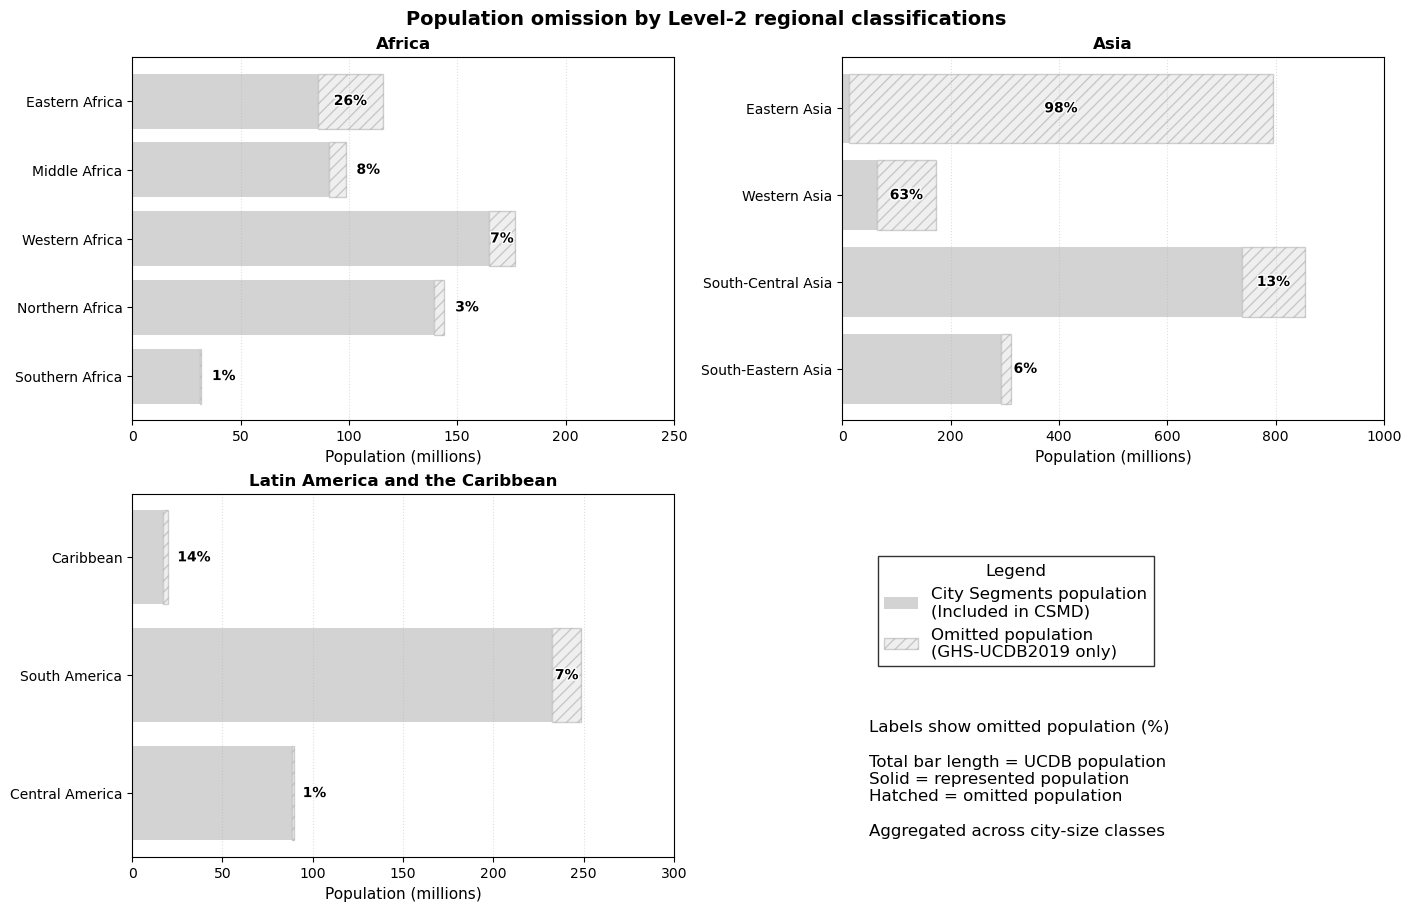

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from pathlib import Path

CSV_PATH = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\regionL1_regionL2_citysize_omission_80pct.csv"
)

OUT_DIR = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

print(df.shape)
print(df.columns.tolist())
df.head()

# Keep only rows where there is at least some UCDB population
df = df[df["UCDB_Pop_M"] > 0].copy()

# Make sure numeric columns are numeric
for col in ["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M", "Omitted_%"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print(df.shape)
df.head()

reg2_df = (
    df
    .groupby(["Region_L1", "Region_L2"], as_index=False)[
        ["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]
    ]
    .sum()
)

reg2_df["Omitted_%"] = np.where(
    reg2_df["UCDB_Pop_M"] > 0,
    (reg2_df["Omitted_Pop_M"] / reg2_df["UCDB_Pop_M"]) * 100,
    0
).round(1)

print(reg2_df.shape)
reg2_df

for region in reg2_df["Region_L1"].unique():
    print("\n", region)
    print(reg2_df.loc[reg2_df["Region_L1"] == region, "Region_L2"].tolist())


REGION_ORDER = ["Africa", "Asia", "Latin America and the Caribbean"]

XMAX_BY_REGION = {
    "Africa": 250,
    "Asia": 1000,
    "Latin America and the Caribbean": 300
}

def plot_reg2_omission_panel(ax, df, region_name, show_title=True):
    sub = df[df["Region_L1"] == region_name].copy()

    # Sort by omitted % descending
    sub = sub.sort_values("Omitted_%", ascending=False)

    cs = sub["CS_Pop_M"].to_numpy()
    omitted = sub["Omitted_Pop_M"].to_numpy()
    labels = sub["Region_L2"].tolist()

    bars1 = ax.barh(
        labels,
        cs,
        color="lightgrey",
        height=0.8,
        label="City Segments population"
    )

    bars2 = ax.barh(
        labels,
        omitted,
        left=cs,
        color="lightgrey",
        alpha=0.35,
        hatch="///",
        edgecolor="grey",
        height=0.8,
        label="Omitted population"
    )

    # Omitted % label
    for bar, cs_val, om_val, pct in zip(bars2, cs, omitted, sub["Omitted_%"]):
        total = cs_val + om_val

        # Put label centered in omitted segment if wide enough,
        # otherwise just outside the bar
        if om_val >= max(8, 0.06 * ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 8):
            x = cs_val + om_val / 2
            ha = "center"
            color = "black"
        else:
            x = total + 5
            ha = "left"
            color = "black"

        txt = ax.text(
            x,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%",
            ha=ha,
            va="center",
            fontsize=10,
            fontweight="bold",
            color=color
        )
        txt.set_path_effects([
            pe.Stroke(linewidth=2, foreground="white"),
            pe.Normal()
        ])

    if show_title:
        ax.set_title(region_name, fontsize=12, fontweight="bold")

    ax.set_xlim(0, XMAX_BY_REGION.get(region_name, sub["UCDB_Pop_M"].max() * 1.15))
    ax.set_xlabel("Population (millions)", fontsize=11)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.invert_yaxis()

    return bars1, bars2

reg2_totals = (
    reg2_df.groupby("Region_L1", as_index=False)[["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]]
    .sum()
)
reg2_totals["Omitted_%"] = (reg2_totals["Omitted_Pop_M"] / reg2_totals["UCDB_Pop_M"] * 100).round(1)
reg2_totals

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

ax_africa = axes[0, 0]
ax_asia   = axes[0, 1]
ax_lac    = axes[1, 0]
ax_leg    = axes[1, 1]

plot_reg2_omission_panel(ax_africa, reg2_df, "Africa")
plot_reg2_omission_panel(ax_asia, reg2_df, "Asia")
plot_reg2_omission_panel(ax_lac, reg2_df, "Latin America and the Caribbean")

ax_leg.set_axis_off()

legend_handles = [
    Patch(facecolor="lightgrey", edgecolor="none", label="City Segments population\n(QC-passed cities)"),
    Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", alpha=0.35, label="Omitted population\n(UCDB only)"),
]

ax_leg.set_axis_off()

legend_handles = [
    Patch(facecolor="lightgrey", edgecolor="none",
          label="City Segments population\n(Included in CSMD)"),
    Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", alpha=0.35,
          label="Omitted population\n(GHS-UCDB2019 only)"),
]

# Move legend higher
ax_leg.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.05, 0.85),
    frameon=True,
    edgecolor="black",
    fancybox=False,
    fontsize=12,
    title="Legend",
    title_fontsize=12,
)

# Move text clearly below legend
info_text = (
    "Labels show omitted population (%)\n\n"
    "Total bar length = UCDB population\n"
    "Solid = represented population\n"
    "Hatched = omitted population\n\n"
    "Aggregated across city-size classes"
)

ax_leg.text(
    0.05,
    0.05,   # push text to bottom
    info_text,
    ha="left",
    va="bottom",
    fontsize=12
)

fig.suptitle(
    "Population omission by Level-2 regional classifications",
    fontsize=14,
    fontweight="bold"
)

plt.show()

In [ ]:
FIG_NAME = "reg2_population_omission_3panel"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig.savefig(
    OUT_DIR / f"{FIG_NAME}.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_DIR / f"{FIG_NAME}.pdf",
    bbox_inches="tight",
    facecolor="white"
)

print("Saved PNG and PDF to:", OUT_DIR)

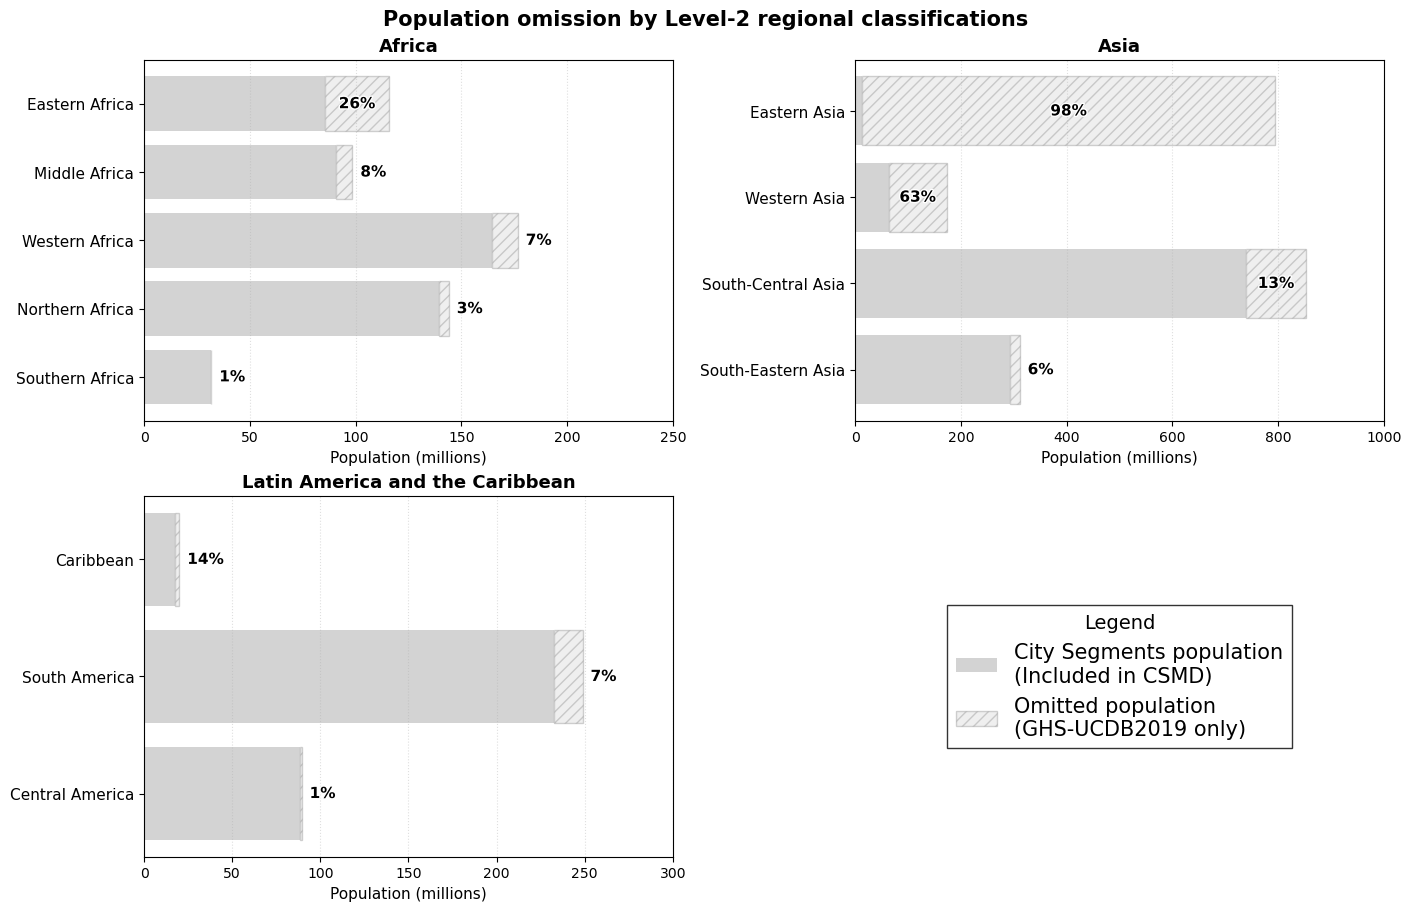

Saved PNG and PDF to: D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
CSV_PATH = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\regionL1_regionL2_citysize_omission_80pct.csv"
)

OUT_DIR = Path(
    r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)

# Keep only rows with UCDB population
df = df[df["UCDB_Pop_M"] > 0].copy()

# Ensure numeric columns
for col in ["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M", "Omitted_%"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# ============================================================
# AGGREGATE TO REGION_L2 LEVEL
# ============================================================
reg2_df = (
    df
    .groupby(["Region_L1", "Region_L2"], as_index=False)[
        ["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]
    ]
    .sum()
)

reg2_df["Omitted_%"] = np.where(
    reg2_df["UCDB_Pop_M"] > 0,
    (reg2_df["Omitted_Pop_M"] / reg2_df["UCDB_Pop_M"]) * 100,
    0
).round(1)

# ============================================================
# SETTINGS
# ============================================================
REGION_ORDER = ["Africa", "Asia", "Latin America and the Caribbean"]

XMAX_BY_REGION = {
    "Africa": 250,
    "Asia": 1000,
    "Latin America and the Caribbean": 300
}

# ============================================================
# PLOTTING FUNCTION
# ============================================================
def plot_reg2_omission_panel(ax, df, region_name):
    sub = df[df["Region_L1"] == region_name].copy()

    # Sort by omitted percentage
    sub = sub.sort_values("Omitted_%", ascending=False)

    cs = sub["CS_Pop_M"].to_numpy()
    omitted = sub["Omitted_Pop_M"].to_numpy()
    labels = sub["Region_L2"].tolist()

    ax.barh(
        labels,
        cs,
        color="lightgrey",
        height=0.8,
        label="City Segments population"
    )

    bars_omit = ax.barh(
        labels,
        omitted,
        left=cs,
        color="lightgrey",
        alpha=0.35,
        hatch="///",
        edgecolor="grey",
        height=0.8,
        label="Omitted population"
    )

    xmax = XMAX_BY_REGION.get(region_name, sub["UCDB_Pop_M"].max() * 1.15)
    ax.set_xlim(0, xmax)

    # Omitted percentage labels
    for bar, cs_val, om_val, pct in zip(bars_omit, cs, omitted, sub["Omitted_%"]):
        total = cs_val + om_val

        if om_val >= max(8, 0.06 * xmax):
            x = cs_val + om_val / 2
            ha = "center"
        else:
            x = total + xmax * 0.015
            ha = "left"

        txt = ax.text(
            x,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%",
            ha=ha,
            va="center",
            fontsize=11,
            fontweight="bold",
            color="black"
        )

        txt.set_path_effects([
            pe.Stroke(linewidth=2, foreground="white"),
            pe.Normal()
        ])

    ax.set_title(region_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Population (millions)", fontsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.invert_yaxis()

# ============================================================
# BUILD FIGURE
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

ax_africa = axes[0, 0]
ax_asia   = axes[0, 1]
ax_lac    = axes[1, 0]
ax_leg    = axes[1, 1]

plot_reg2_omission_panel(ax_africa, reg2_df, "Africa")
plot_reg2_omission_panel(ax_asia, reg2_df, "Asia")
plot_reg2_omission_panel(ax_lac, reg2_df, "Latin America and the Caribbean")

# ============================================================
# LEGEND-ONLY PANEL
# ============================================================
ax_leg.set_axis_off()

legend_handles = [
    Patch(
        facecolor="lightgrey",
        edgecolor="none",
        label="City Segments population\n(Included in CSMD)"
    ),
    Patch(
        facecolor="lightgrey",
        edgecolor="grey",
        hatch="///",
        alpha=0.35,
        label="Omitted population\n(GHS-UCDB2019 only)"
    ),
]

ax_leg.legend(
    handles=legend_handles,
    loc="center",
    frameon=True,
    edgecolor="black",
    fancybox=False,
    fontsize=15,
    title="Legend",
    title_fontsize=14,
)

# ============================================================
# TITLE + SAVE
# ============================================================
fig.suptitle(
    "Population omission by Level-2 regional classifications",
    fontsize=15,
    fontweight="bold"
)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

FIG_NAME = "reg2_population_omission_3panel_refined"

fig.savefig(
    OUT_DIR / f"{FIG_NAME}.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_DIR / f"{FIG_NAME}.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved PNG and PDF to:", OUT_DIR)